## Initialization

In [6]:
import pandas as pd
import numpy as np
import os
import kagglehub
import torch

In [7]:
DATASET_PATH = "/kaggle/input/datasets/rvshekar/ver2-unified-captcha-dataset/captcha-unified"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [8]:
meta_df = pd.read_csv("/kaggle/input/datasets/rvshekar/ver2-unified-captcha-dataset/captcha-unified/metadata.csv")
train_df = pd.read_csv("/kaggle/input/datasets/rvshekar/ver2-unified-captcha-dataset/captcha-unified/train.csv")
test_df = pd.read_csv("/kaggle/input/datasets/rvshekar/ver2-unified-captcha-dataset/captcha-unified/test.csv")
val_df = pd.read_csv("/kaggle/input/datasets/rvshekar/ver2-unified-captcha-dataset/captcha-unified/val.csv")

train_df = train_df.drop(columns=["original_filename", "original_path", "extension", "sha256"])
test_df = test_df.drop(columns=["original_filename", "original_path", "extension", "sha256"])
val_df = val_df.drop(columns=["original_filename", "original_path", "extension", "sha256"])

train_df[65:70]

,image_id,label,source_type,captcha_length,image_path
65,266814,vzcBo9,samoilovmikhail,6,images/samoilovmikhail/00266815.png
66,96263,2iOJY,parsasam,5,images/parsasam/00096263.jpg
67,193263,23J4bH,rvshekar,6,images/rvshekar/00193264.png
68,137578,Y5Q8OkGPfS,aadhavvignesh,10,images/aadhavvignesh/00137578.jpg
69,334116,8BBKc8,samoilovmikhail,6,images/samoilovmikhail/00334117.png


In [9]:
meta_df.shape

(355750, 9)

In [10]:
i = 12345
img_path = os.path.join(DATASET_PATH, train_df["image_path"][i])

os.path.exists(img_path)

True

In [11]:
print(val_df["captcha_length"].value_counts())

captcha_length
5     15534
6     15049
10      900
4       535
Name: count, dtype: int64


In [12]:
# testing the image dimensions

from PIL import Image
import numpy as np

sample_df = meta_df.sample(1000, random_state=42)

widths = []
heights = []
modes = []

for _, row in sample_df.iterrows():
    path = os.path.join(DATASET_PATH, row["image_path"])

    with Image.open(path) as img:
        widths.append(img.width)
        heights.append(img.height)
        modes.append(img.mode)

print("Width:")
print("  min:", min(widths))
print("  max:", max(widths))
print("  mean:", np.mean(widths))
print("  median:", np.median(widths))

print("\nHeight:")
print("  min:", min(heights))
print("  max:", max(heights))
print("  mean:", np.mean(heights))
print("  median:", np.median(heights))

print("\nImage modes:")
print(set(modes))

Width:
  min: 128
  max: 282
  mean: 193.856
  median: 150.0

Height:
  min: 40
  max: 128
  mean: 63.718
  median: 50.0

Image modes:
{'L', 'RGB', 'RGBA'}


## Data and Preprocessing

In [13]:
# building character vocabulary for CTC

characters = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

char2idx = {
    char : idx
    for idx, char in enumerate(characters)
}

idx2char = {
    idx : char
    for char, idx in char2idx.items()
}

BLANK_IDX = len(characters)

In [14]:
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

class CaptchaDataset(Dataset):

    def __init__(self, df, dataset_path, char2idx, image_height=48):
        self.df = df
        self.dataset_path = dataset_path
        self.char2idx = char2idx
        self.image_height = image_height

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        #image
        image_path = os.path.join(self.dataset_path, row["image_path"])
        image = Image.open(image_path).convert("RGB")
        
        original_width, original_height = image.size

        new_height = self.image_height
        new_width = round((original_width * new_height) / original_height)

        image = image.resize((new_width, new_height), Image.Resampling.LANCZOS) # LANCOZ is an image interpolation method

        image = np.array(image, dtype=np.float32) / 255.0
        image_tensor = torch.from_numpy(image)
        image_tensor = image_tensor.permute(2, 0, 1)

        #label
        label = row["label"]

        encoded_label = torch.tensor([self.char2idx[c] for c in label], dtype=torch.long)

        return image_tensor, encoded_label, label, new_width

In [15]:
# creating all datasets

IMAGE_HEIGHT = 48

train_dataset = CaptchaDataset(
    train_df,
    DATASET_PATH,
    char2idx,
    IMAGE_HEIGHT
)

test_dataset = CaptchaDataset(
    test_df,
    DATASET_PATH,
    char2idx,
    IMAGE_HEIGHT
)

val_dataset = CaptchaDataset(
    val_df,
    DATASET_PATH,
    char2idx,
    IMAGE_HEIGHT
)

In [16]:
# collate function to manage the variable width of images in each batch

def captcha_collate_fn(batch):

    image_tensors, encoded_labels, labels, widths = zip(*batch)

    max_width = max(widths)
    batch_size = len(image_tensors)

    batch_images = torch.zeros(
        batch_size,
        3,
        IMAGE_HEIGHT,
        max_width,
        dtype = torch.float32
    )

    for i, img in enumerate(image_tensors):
        width = img.shape[2]
        batch_images[i, :, :, :width] = img

    targets = torch.cat(encoded_labels) # concatenating all the encoded_labels into a single tensor
    
    label_lengths = torch.tensor(
        [len(label) for label in labels],
        dtype = torch.long
    )

    widths = torch.tensor(widths, dtype=torch.long)

    return (batch_images, targets, label_lengths, labels, widths)

In [17]:
# creating dataloaders for all datasets

BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    collate_fn = captcha_collate_fn,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 4,
    pin_memory = True
)

test_loader = DataLoader(
    test_dataset,
    collate_fn = captcha_collate_fn,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 4,
    pin_memory = True
)

val_loader = DataLoader(
    val_dataset,
    collate_fn = captcha_collate_fn,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 4,
    pin_memory = True
)

In [15]:
# testing the loaders

image_tensors, targets, label_lengths, labels, widths = next(iter(train_loader))

print("Images shape:", image_tensors.shape)
print("Targets shape:", targets.shape)
print("Label lengths shape:", label_lengths.shape)

print("\nFirst 5 labels:")
print(labels[:5])

print("\nFirst 5 encoded labels:")
print(targets[:sum(label_lengths[:5])])

print("\nFirst 5 original widths:")
print(widths[:5])

Images shape: torch.Size([128, 3, 48, 240])
Targets shape: torch.Size([736])
Label lengths shape: torch.Size([128])

First 5 labels:
('1Y02NV3soe', '7t2rS', 'vFy0FE', 'BsWrQt', 'be76Hmr3sM')

First 5 encoded labels:
tensor([ 1, 34,  0,  2, 23, 31,  3, 54, 50, 40,  7, 55,  2, 53, 28, 57, 15, 60,
         0, 15, 14, 11, 54, 32, 53, 26, 55, 37, 40,  7,  6, 17, 48, 53,  3, 54,
        22])

First 5 original widths:
tensor([150, 180, 149, 144, 150])


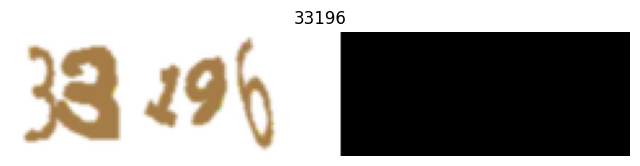

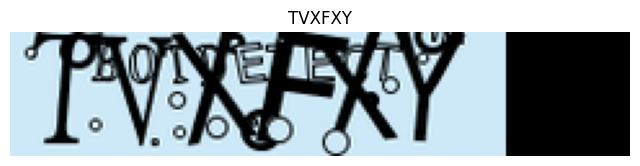

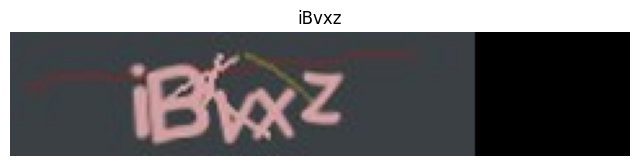

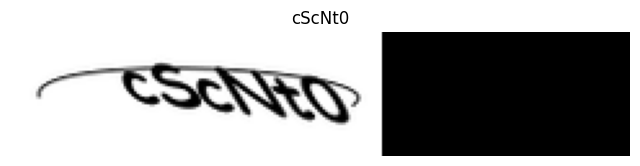

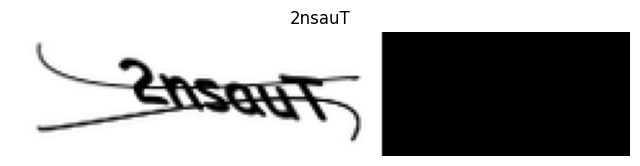

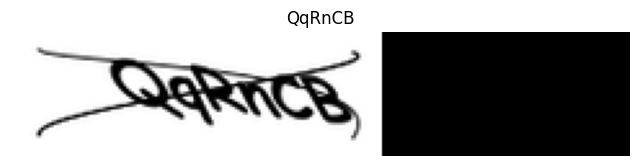

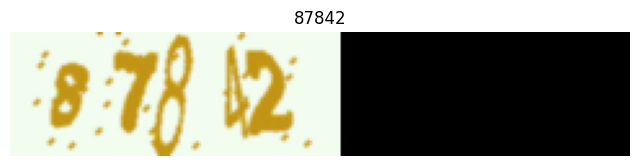

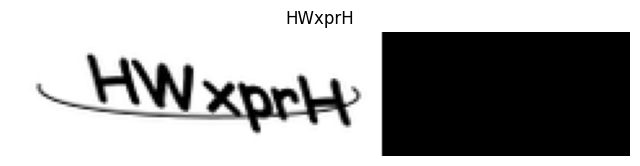

In [16]:
# manually inspecting the image after preprocessing

import matplotlib.pyplot as plt

images, targets, label_lengths, labels, widths = next(iter(train_loader))

for i in range(8):
    plt.figure(figsize=(8, 2))
    plt.imshow(images[i].permute(1, 2, 0))
    plt.title(labels[i])
    plt.axis("off")
    plt.show()

## Model

In [18]:
# building the CNN

import torch
import torch.nn as nn

class CNNEncoder(nn.Module):
    
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.cnn(x)


cnn_encoder = CNNEncoder()

In [19]:
# testing the cnn output size

image_tensors, targets, label_lengths, labels, widths = next(iter(train_loader))

img_features = cnn_encoder(image_tensors)

print("Input shape:", image_tensors.shape)
print("CNN output shape:", img_features.shape)

Input shape: torch.Size([128, 3, 48, 240])
CNN output shape: torch.Size([128, 256, 12, 60])


In [20]:
class BiLSTM(nn.Module):
    def __init__(self, input_size=3072, projection_size=256, hidden_size=256):
        super().__init__()

        self.projection = nn.Linear(input_size, projection_size)

        self.lstm = nn.LSTM(
            input_size = projection_size,
            hidden_size = hidden_size,
            num_layers=2,
            dropout=0.2,
            bidirectional = True
        )

    def forward(self, x):
        x = self.projection(x)
        x, _ = self.lstm(x) # [W, B, 256+256] because of forward + backward
        return x


bilstm_encoder = BiLSTM()

In [21]:
import torch.nn.functional as F

class CharacterClassifier(nn.Module):
    def __init__(self, input_size=512, num_classes=63):
        super().__init__()

        self.fc = nn.Linear(input_size, num_classes)

    def forward(self, x):
        x = self.fc(x)
        return x


character_classifier = CharacterClassifier()

In [22]:
class CAPTCHARecognizer(nn.Module):
    def __init__(self, cnn, bilstm, classifier):
        super().__init__()
        
        self.cnn = cnn
        self.bilstm = bilstm
        self.classifier = classifier

    def forward(self, x):
        x = self.cnn(x)

        # reshaping the output from cnn in order to feed the BiLSTM
        B, C, H, W = x.shape
        x = x.permute(3, 0, 1, 2)
        x = x.reshape(W, B, C*H)

        x = self.bilstm(x)
        x = self.classifier(x)

        return x

In [23]:
model = CAPTCHARecognizer(
    cnn = cnn_encoder,
    bilstm = bilstm_encoder,
    classifier = character_classifier
)

model = model.to(device)

## Training

In [23]:
# testing the model 

image_tensors, targets, label_lengths, labels, widths = next(iter(train_loader))
image_tensors = image_tensors.to(device, non_blocking=True)

logits = model(image_tensors)
print(logits)

tensor([[[-0.0591,  0.0185, -0.0335,  ..., -0.0739, -0.0015,  0.0282],
         [-0.0685,  0.0214, -0.0283,  ..., -0.0569, -0.0137,  0.0148],
         [-0.0603,  0.0264, -0.0299,  ..., -0.0617, -0.0114,  0.0165],
         ...,
         [-0.0628,  0.0367, -0.0464,  ..., -0.0469, -0.0030,  0.0213],
         [-0.0451,  0.0164, -0.0556,  ..., -0.0324, -0.0248,  0.0222],
         [-0.0519,  0.0268, -0.0289,  ..., -0.0701, -0.0026,  0.0110]],

        [[-0.0669,  0.0198, -0.0479,  ..., -0.0672,  0.0050,  0.0362],
         [-0.0715,  0.0045, -0.0432,  ..., -0.0625, -0.0062,  0.0040],
         [-0.0617,  0.0278, -0.0426,  ..., -0.0534, -0.0133,  0.0330],
         ...,
         [-0.0777,  0.0326, -0.0655,  ..., -0.0301, -0.0151,  0.0188],
         [-0.0446,  0.0239, -0.0665,  ..., -0.0171, -0.0304,  0.0145],
         [-0.0640,  0.0151, -0.0490,  ..., -0.0723, -0.0015,  0.0255]],

        [[-0.0827,  0.0195, -0.0542,  ..., -0.0629,  0.0039,  0.0340],
         [-0.0706, -0.0013, -0.0374,  ..., -0

In [24]:
criterion = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

In [26]:
# lr scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-5
)

In [27]:
# creating sample loaders to test the training loop

from torch.utils.data import DataLoader, Subset

test_train_dataset = Subset(
    train_dataset,
    range(min(200, len(train_dataset)))
)

test_val_dataset = Subset(
    val_dataset,
    range(min(50, len(val_dataset)))
)

test_train_loader = DataLoader(
    test_train_dataset,
    collate_fn = captcha_collate_fn,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_val_loader = DataLoader(
    test_val_dataset,
    collate_fn = captcha_collate_fn,
    batch_size=16,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [28]:
# loading previous best model weights

bestModel_path = "/kaggle/input/models/rvshekar/best-captcha-weights/pytorch/default/1/best_captcha_model (3).pth"

model.load_state_dict(
    torch.load(bestModel_path, map_location=device, weights_only=True)
)

<All keys matched successfully>

In [ ]:
# training loop

import time
from difflib import SequenceMatcher

epochs = 50

best_val_loss = float("inf")
best_exact_match = 0.0

for epoch in range(epochs):

    epoch_start_time = time.time()

    # Training
    model.train()

    total_train_loss = 0.0
    total_train_samples = 0

    for batch_images, targets, label_lengths, labels, widths in train_loader:

        batch_images = batch_images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        label_lengths = label_lengths.to(device, non_blocking=True)
        input_lengths = (widths // 4).to(device, non_blocking=True)

        optimizer.zero_grad()

        # Forward pass
        logits = model(batch_images)

        # CTC expects log probabilities
        log_probs = logits.log_softmax(dim=2)

        # CTC loss
        loss = criterion(
            log_probs,
            targets,
            input_lengths,
            label_lengths
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()

        batch_size = batch_images.size(0)

        total_train_loss += loss.item() * batch_size
        total_train_samples += batch_size

    avg_train_loss = total_train_loss / total_train_samples

    # Validation
    model.eval()

    total_val_loss = 0.0
    total_val_samples = 0

    correct_captchas = 0
    total_captchas = 0

    correct_characters = 0
    total_characters = 0

    with torch.no_grad():

        for batch_images, targets, label_lengths, labels, widths in val_loader:

            batch_images = batch_images.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            label_lengths = label_lengths.to(device, non_blocking=True)
            input_lengths = (widths // 4).to(device, non_blocking=True)

            # Forward pass
            logits = model(batch_images)

            # CTC loss
            log_probs = logits.log_softmax(dim=2)

            loss = criterion(
                log_probs,
                targets,
                input_lengths,
                label_lengths
            )

            batch_size = batch_images.size(0)

            total_val_loss += loss.item() * batch_size
            total_val_samples += batch_size

            # Greedy CTC decoding
            predictions = logits.argmax(dim=2)

            for i in range(batch_size):

                pred = predictions[:input_lengths[i], i]

                decoded = []
                previous = None

                for char_id in pred.tolist():

                    # 62 is the CTC blank
                    if char_id == 62:
                        previous = char_id
                        continue

                    # Remove consecutive duplicates
                    if char_id != previous:
                        decoded.append(char_id)

                    previous = char_id

                # Convert IDs to characters
                predicted_text = "".join(
                    idx2char[idx] for idx in decoded
                )

                actual_text = labels[i]

                # Exact match
                if predicted_text == actual_text:
                    correct_captchas += 1

                total_captchas += 1

                # Character accuracy
                matcher = SequenceMatcher(
                    None,
                    actual_text,
                    predicted_text
                )

                matching_characters = sum(
                    block.size
                    for block in matcher.get_matching_blocks()
                )

                correct_characters += matching_characters
                total_characters += len(actual_text)

    avg_val_loss = total_val_loss / total_val_samples
    exact_match_acc = correct_captchas / total_captchas
    character_acc = correct_characters / total_characters

    # Update learning rate based on validation loss
    scheduler.step(avg_val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    epoch_time = (time.time() - epoch_start_time) / 60

    print(
        f"Epoch: {epoch + 1} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Character Acc: {character_acc:.4%} | "
        f"Exact Match: {exact_match_acc:.4%} | "
        f"LR: {current_lr:.2e} | "
        f"Time: {epoch_time:.2f} mins"
    )

    # Save best model
    if exact_match_acc > best_exact_match:
        best_exact_match = exact_match_acc
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_captcha_model.pth")
        print("Best model saved.")

    # Save checkpoint
    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_loss": avg_train_loss,
            "val_loss": avg_val_loss,
            "val_character_accuracy": character_acc,
            "val_exact_match_accuracy": exact_match_acc,
            "best_val_loss": best_val_loss
        },
        "ckpt_captcha_model.pth"
    )

Epoch: 1 | Train Loss: 0.2094 | Val Loss: 0.1285 | Character Acc: 95.2938% | Exact Match: 81.2199% | LR: 1.00e-03 | Time: 47.69 mins
Best model saved.
Epoch: 2 | Train Loss: 0.0907 | Val Loss: 0.1059 | Character Acc: 95.9990% | Exact Match: 84.3088% | LR: 1.00e-03 | Time: 11.99 mins
Best model saved.
Epoch: 3 | Train Loss: 0.0785 | Val Loss: 0.1024 | Character Acc: 96.0386% | Exact Match: 84.6212% | LR: 1.00e-03 | Time: 11.08 mins
Best model saved.
Epoch: 4 | Train Loss: 0.0722 | Val Loss: 0.0974 | Character Acc: 96.2296% | Exact Match: 85.5238% | LR: 1.00e-03 | Time: 10.06 mins
Best model saved.
Epoch: 5 | Train Loss: 0.0680 | Val Loss: 0.1021 | Character Acc: 96.0397% | Exact Match: 84.8054% | LR: 1.00e-03 | Time: 12.06 mins
Epoch: 6 | Train Loss: 0.0653 | Val Loss: 0.0933 | Character Acc: 96.4004% | Exact Match: 86.3983% | LR: 1.00e-03 | Time: 10.58 mins
Best model saved.
Epoch: 7 | Train Loss: 0.0625 | Val Loss: 0.0894 | Character Acc: 96.4836% | Exact Match: 86.9167% | LR: 1.00e-0

## Testing

In [24]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CAPTCHARecognizer(
    cnn = cnn_encoder,
    bilstm = bilstm_encoder,
    classifier = character_classifier
)
model = model.to(device)

checkpoint = torch.load(
    "/kaggle/working/best_captcha_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint)

model.eval()

print("Model loaded successfully!")

Model loaded successfully!


In [25]:
def ctc_decode(logits, idx2char, blank_idx):

    predictions = logits.argmax(dim=2)   # [T, B]

    decoded = []

    for b in range(predictions.size(1)):

        sequence = predictions[:, b].tolist()

        result = []
        previous = None

        for idx in sequence:

            # Ignore blank
            if idx == blank_idx:
                previous = idx
                continue

            # Remove consecutive duplicates
            if idx != previous:
                result.append(idx)

            previous = idx

        text = "".join(idx2char[idx] for idx in result)

        decoded.append(text)

    return decoded

In [26]:
# running the model on the test_loader

from difflib import SequenceMatcher

model.eval()

total_samples = 0
exact_correct = 0

total_chars = 0
correct_chars = 0

with torch.no_grad():

    for images, targets, label_lengths, labels, widths in test_loader:

        images = images.to(device)

        # Forward pass
        logits = model(images)

        # CTC greedy decoding
        predictions = ctc_decode(
            logits,
            idx2char,
            BLANK_IDX
        )

        # Calculate metrics for this batch
        for actual, predicted in zip(labels, predictions):

            total_samples += 1

            # Exact-match accuracy
            if actual == predicted:
                exact_correct += 1

            # Character accuracy
            matcher = SequenceMatcher(
                None,
                actual,
                predicted
            )

            for tag, i1, i2, j1, j2 in matcher.get_opcodes():

                # Characters correctly matched
                if tag == "equal":
                    correct_chars += (i2 - i1)

                # All ground-truth characters count
                total_chars += (i2 - i1)


# Final metrics
exact_match_accuracy = exact_correct / total_samples
character_accuracy = correct_chars / total_chars

print(f"Test samples:          {total_samples}")
print(f"Exact-match accuracy:  {exact_match_accuracy * 100:.2f}%")
print(f"Character accuracy:    {character_accuracy * 100:.2f}%")

Test samples:          35576
Exact-match accuracy:  89.84%
Character accuracy:    97.11%


In [27]:
# checking the types of errors

all_actual = []
all_predicted = []

model.eval()

with torch.no_grad():

    for images, targets, label_lengths, labels, widths in test_loader:

        images = images.to(device)

        logits = model(images)

        predictions = ctc_decode(
            logits,
            idx2char,
            BLANK_IDX
        )

        # Store ground-truth and predictions
        all_actual.extend(labels)
        all_predicted.extend(predictions)



exact_correct = 0
wrong_length = 0
wrong_character = 0

for actual, predicted in zip(all_actual, all_predicted):

    if actual == predicted:
        exact_correct += 1

    elif len(actual) != len(predicted):
        wrong_length += 1

    else:
        wrong_character += 1

print("Exact correct:", exact_correct)
print("Wrong length: ", wrong_length)
print("Wrong chars:  ", wrong_character)

Exact correct: 31966
Wrong length:  123
Wrong chars:   3487


## Inference

In [98]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt


def predict_greedy(image_path, model):

    # Load image
    image = Image.open(image_path).convert("RGB")

    original_width, original_height = image.size

    new_height = IMAGE_HEIGHT
    new_width = round((original_width * new_height) / original_height)

    image = image.resize(
        (new_width, new_height),
        Image.Resampling.LANCZOS
    )

    # Display image after preprocessing
    plt.figure(figsize=(10, 3))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Preprocessed Image: {new_width} × {new_height}")
    plt.show()

    # Convert to numpy
    image = np.array(image, dtype=np.float32) / 255.0

    image = torch.from_numpy(image)

    # HWC → CHW
    image = image.permute(2, 0, 1)

    # CHW → BCHW
    image = image.unsqueeze(0).to(device)


    # Model inference
    model.eval()

    with torch.no_grad():

        logits = model(image)

        # Convert logits to probabilities
        probabilities = torch.softmax(logits, dim=2)

        # Most likely class at every timestep
        predictions = probabilities.argmax(dim=2)


    # CTC decoding + confidence
    sequence = predictions[:, 0].tolist()

    decoded = []
    character_confidences = []

    previous = None

    for t, char_id in enumerate(sequence):

        if char_id == BLANK_IDX:
            previous = char_id
            continue

        # Consecutive duplicate
        if char_id == previous:
            previous = char_id
            continue

        # Keep this character
        decoded.append(char_id)

        # Probability of the selected character
        confidence = probabilities[t, 0, char_id].item()

        character_confidences.append(confidence)

        previous = char_id


    # Convert IDs → characters
    prediction = "".join(idx2char[idx] for idx in decoded)

    # Overall confidence
    if character_confidences:
        confidence = sum(character_confidences) / len(character_confidences)
    else:
        confidence = 0.0


    return prediction, confidence, character_confidences

In [102]:
from pathlib import Path

for path in Path("/kaggle/working").iterdir():
    if path.suffix.lower() in [".png", ".jpg", ".jpeg"]:
        path.unlink()

print("Images deleted.")

Images deleted.


In [40]:
from IPython.display import display
import ipywidgets as widgets
from PIL import Image
import matplotlib.pyplot as plt

upload = widgets.FileUpload(
    accept='image/*',
    multiple=False
)

display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

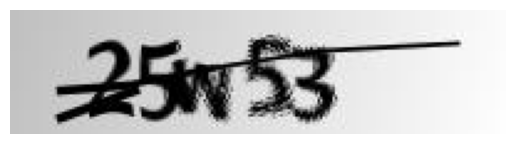

In [103]:
# converting the uploaded img to suitable form
uploaded_file = upload.value[0]

image_path = uploaded_file["name"]

with open(image_path, "wb") as f:
    f.write(uploaded_file["content"])

# displaying the image
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.show()

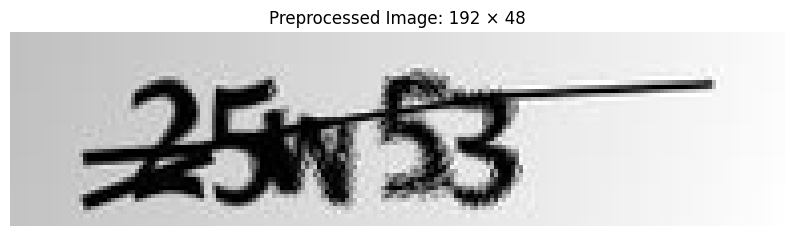

Predicted CAPTCHA: 25w53
Confidence: 99.75%


In [104]:

prediction, confidence, character_confidences = predict_greedy(
    image_path,
    model
)

print("Predicted CAPTCHA:", prediction)
print(f"Confidence: {confidence:.2%}")
